In [46]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os

# ====== USER CONFIG ===========================================================
CSV_PATH = Path("/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t5/synched_data/final_annotation_t5.csv")   # <— change if needed

# If you know the label column, set it here; else it will be auto-guessed.
LABEL_COL = None  # e.g., "gesture" or "activity"

# Choose which modality to run PCA on (any key from MODALITY_COLUMNS below).
MODALITY_KEY = "console"        # e.g., "console", "raven", "trakstar_raw", "trakstar_trans", "handkp", "images"

# How many PCs to compute (>= max(PC_PAIR))
N_COMPONENTS = 4                # e.g., 3, 6, 10 …

# Which two PCs to show (1-based indices): (1,2) or (1,3) or (2,3), etc.
PC_PAIR = (1, 2)

# Optional downsampling for faster plots (keep 1 to use all rows)
DOWNSAMPLE_EVERY_N_ROWS = 1

# Save figures?
SAVE_FIGS = True
OUTDIR = Path("./pca_outputs")
os.makedirs(OUTDIR, exist_ok=True)
# ==============================================================================


# ====== YOUR COLUMN LISTS =====================================================
MODALITY_COLUMNS = {
    "console": [
        "console_pos0","console_pos1","console_pos2","console_pos3","console_pos4","console_pos5",
        "console_rot0","console_rot1","console_rot2","console_rot3","console_rot4","console_rot5",
        "console_aux0","console_aux1","console_pedal"
    ],
    "raven": [
        "raven_field.pos0","raven_field.pos1","raven_field.pos2","raven_field.pos3","raven_field.pos4","raven_field.pos5",
        "raven_field.ori0","raven_field.ori1","raven_field.ori2","raven_field.ori3","raven_field.ori4","raven_field.ori5",
        # Uncomment if you want all orientation channels:
        # "raven_field.ori6","raven_field.ori7","raven_field.ori8","raven_field.ori9","raven_field.ori10","raven_field.ori11",
        # "raven_field.ori12","raven_field.ori13","raven_field.ori14","raven_field.ori15","raven_field.ori16","raven_field.ori17"
    ],
    # Placeholder if you later add columns for framewise ResNet feats (e.g., resnet_0..2047)
    "images": ["resnet"],

    # Two flavors of TrakStar (raw and transformed); pick the key you want
    "trakstar_raw": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x","trakstar_sensor_1_x","trakstar_sensor_2_x","trakstar_sensor_3_x",
        "trakstar_sensor_0_y","trakstar_sensor_1_y","trakstar_sensor_2_y","trakstar_sensor_3_y",
        "trakstar_sensor_0_z","trakstar_sensor_1_z","trakstar_sensor_2_z","trakstar_sensor_3_z"
    ],
    "trakstar_trans": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x_transformed","trakstar_sensor_0_y_transformed","trakstar_sensor_0_z_transformed",
        "trakstar_sensor_1_x_transformed","trakstar_sensor_1_y_transformed","trakstar_sensor_1_z_transformed",
        "trakstar_sensor_2_x_transformed","trakstar_sensor_2_y_transformed","trakstar_sensor_2_z_transformed",
        "trakstar_sensor_3_x_transformed","trakstar_sensor_3_y_transformed","trakstar_sensor_3_z_transformed"
        # ,"trakstar_grasp_d0","trakstar_grasp_d1"
    ],

    "sw_left":  ["sw_left_x"],
    "sw_right": ["sw_right_x"],

    "handkp": [
        "hand_left X","hand_left Y","hand_left Z","hand_left Yaw","hand_left Pitch","hand_left Roll",
        "hand_right X","hand_right Y","hand_right Z","hand_right Yaw","hand_right Pitch","hand_right Roll"
        # If you want fingertips later, append:
        # ,"hand_left_index_tip_X","hand_left_index_tip_Y","hand_left_index_tip_Z",
        #  "hand_right_index_tip_X","hand_right_index_tip_Y","hand_right_index_tip_Z",
        #  "hand_left_thumb_tip_X","hand_left_thumb_tip_Y","hand_left_thumb_tip_Z",
        #  "hand_right_thumb_tip_X","hand_right_thumb_tip_Y","hand_right_thumb_tip_Z"
    ],
}


# ====== UTILITIES ==============================================================

def guess_label_column(df: pd.DataFrame) -> str:
    preferred = ["gesture", "gesture_label", "activity", "activity_label",
                 "label", "keystep", "keystep_label", "gesture_name", "class"]
    for name in preferred:
        for c in df.columns:
            if c.lower() == name.lower():
                return c
    # fallback: pick a low-cardinality column
    candidates = []
    for c in df.columns:
        lower = c.lower()
        if any(t in lower for t in ["time", "timestamp", "frame", "index"]):
            continue
        nunique = df[c].nunique(dropna=True)
        if 1 < nunique <= 40:
            if df[c].dtype == object:
                candidates.append((c, nunique))
            else:
                if nunique / max(1, len(df)) < 0.05:
                    candidates.append((c, nunique))
    if candidates:
        candidates.sort(key=lambda x: x[1])
        return candidates[0][0]
    df["_auto_label"] = "all"
    return "_auto_label"


def build_feature_matrix(df: pd.DataFrame, cols: list[str]) -> tuple[np.ndarray, list[str]]:
    """Return (X, used_cols) after intersecting with df and warning on any missing."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"[Warn] {len(missing)} columns not found and will be skipped (showing up to 8): {missing[:8]}")
    used = [c for c in cols if c in df.columns]
    if not used:
        raise ValueError("None of the requested modality columns exist in the CSV.")
    X = df[used].to_numpy()
    return X, used


def pca_plot(X: np.ndarray, y: np.ndarray, modality_name: str,
             n_components: int, pc_pair: tuple[int, int], save_dir) -> None:
    # Drop rows with NaNs in the selected features
    valid = np.isfinite(X).all(axis=1)
    X = X[valid]
    y = y[valid]
    if X.shape[0] < 10:
        raise ValueError(f"Not enough valid rows after NaN filtering: {X.shape[0]}")

    # Standardize then PCA
    Xs = StandardScaler().fit_transform(X)
    n_components = int(max(n_components, max(pc_pair)))  # ensure we have enough PCs
    pca = PCA(n_components=n_components).fit(Xs)
    Z = pca.transform(Xs)  # [n, n_components]

    i, j = pc_pair
    pc_i, pc_j = i - 1, j - 1
    if pc_i >= Z.shape[1] or pc_j >= Z.shape[1]:
        raise ValueError(f"PC_PAIR {pc_pair} exceeds computed components ({Z.shape[1]}). Increase N_COMPONENTS.")

    # Scatter PCi vs PCj
    plt.figure(figsize=(8, 6))
    y_cat = pd.Series(y).astype("category")
    codes = y_cat.cat.codes.values
    for code in np.unique(codes):
        idx = codes == code
        plt.scatter(Z[idx, pc_i], Z[idx, pc_j], s=8, alpha=0.7, label=str(y_cat.cat.categories[code]))
    plt.xlabel(f"PC{i} ({pca.explained_variance_ratio_[pc_i]:.2%})")
    plt.ylabel(f"PC{j} ({pca.explained_variance_ratio_[pc_j]:.2%})")
    plt.title(f"{modality_name} — PCA (PC{i} vs PC{j})")
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.tight_layout()
    if SAVE_FIGS and save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_dir / f"{modality_name}_PC{i}_vs_PC{j}.png", dpi=200)
    plt.show()

    # Explained variance bar plot
    evr = pca.explained_variance_ratio_
    plt.figure(figsize=(7, 4))
    xs = np.arange(1, len(evr) + 1)
    plt.bar(xs, evr)
    plt.xticks(xs, [f"PC{k}" for k in xs])
    plt.ylabel("Explained variance ratio")
    plt.title(f"{modality_name} — PCA explained variance (first {len(evr)} PCs)")
    plt.tight_layout()
    if SAVE_FIGS and save_dir:
        plt.savefig(save_dir / f"{modality_name}_explained_variance.png", dpi=200)
    plt.show()

    # Optional quick separation metric on the shown 2D plane
    if len(np.unique(y)) > 1:
        try:
            sil = silhouette_score(Z[:, [pc_i, pc_j]], y_cat.cat.codes.values, metric="euclidean")
            print(f"[Info] Silhouette on PC{i}–PC{j}: {sil:.3f}  (≈[-1,1], higher=better separation)")
        except Exception as e:
            print(f"[Warn] Silhouette failed: {e}")

    # Also print cumulative variance for convenience
    cum = np.cumsum(evr)
    print("[Info] Cumulative explained variance:")
    for k in range(1, min(10, len(evr)) + 1):
        print(f"  PCs 1..{k}: {cum[k-1]:.2%}")


def do_pca_analysis():
    df = pd.read_csv(CSV_PATH)
    print(df.columns.tolist())

    # drop rows where column console_pedal is 0
    df = df[df["console_pedal"] != 0]

    label_col = LABEL_COL or guess_label_column(df)
    print(f"[Label] Using label column: {label_col!r}")
    labels = df[label_col].astype(str).values

    if MODALITY_KEY not in MODALITY_COLUMNS:
        raise KeyError(f"MODALITY_KEY '{MODALITY_KEY}' not in {list(MODALITY_COLUMNS.keys())}")

    cols = MODALITY_COLUMNS[MODALITY_KEY]
    print(f"[Modality] {MODALITY_KEY} with {len(cols)} requested columns")
    X, used_cols = build_feature_matrix(df, cols)
    print(f"[Modality] Using {len(used_cols)} columns found in CSV")

    # Optional downsampling
    if DOWNSAMPLE_EVERY_N_ROWS > 1:
        X = X[::DOWNSAMPLE_EVERY_N_ROWS]
        y = labels[::DOWNSAMPLE_EVERY_N_ROWS]
    else:
        y = labels

    pca_plot(X, y, MODALITY_KEY, N_COMPONENTS, PC_PAIR, save_dir=OUTDIR if SAVE_FIGS else None)




['frame_number', 'timestamp', 'gesture_code', 'gesture_name', 'obs_frame_idx', 'server_time', 'pds_time_ns', 'pds_delta_ns', 'trakstar_time_ns', 'trakstar_delta_ns', 'sw_left_time_ns', 'sw_left_delta_ns', 'sw_right_time_ns', 'sw_right_delta_ns', 'raven_console_time_ns', 'raven_console_delta_ns', 'Pedal 1 Pressure', 'Pedal 2 Pressure', 'Pedal 3 Pressure', 'Pedal 4 Pressure', 'Pedal 6 Pressure', 'Pedal 7 Pressure', 'Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'Pedal 5 Pressesd', 'Pedal 6 Pressed', 'Pedal 7 Pressed', 'trakstar_sensor_0_azimuth', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_azimuth', 'trakstar_sensor_3_azimuth', 'trakstar_sensor_0_elevation', 'trakstar_sensor_1_elevation', 'trakstar_sensor_2_elevation', 'trakstar_sensor_3_elevation', 'trakstar_sensor_0_roll', 'trakstar_sensor_1_roll', 'trakstar_sensor_2_roll', 'trakstar_sensor_3_roll', 'trakstar_sensor_0_x', 'trakstar_sensor_1_x', 'trakstar_sensor_2_x', 'trakstar_sensor_3_x', 'trakstar_sen

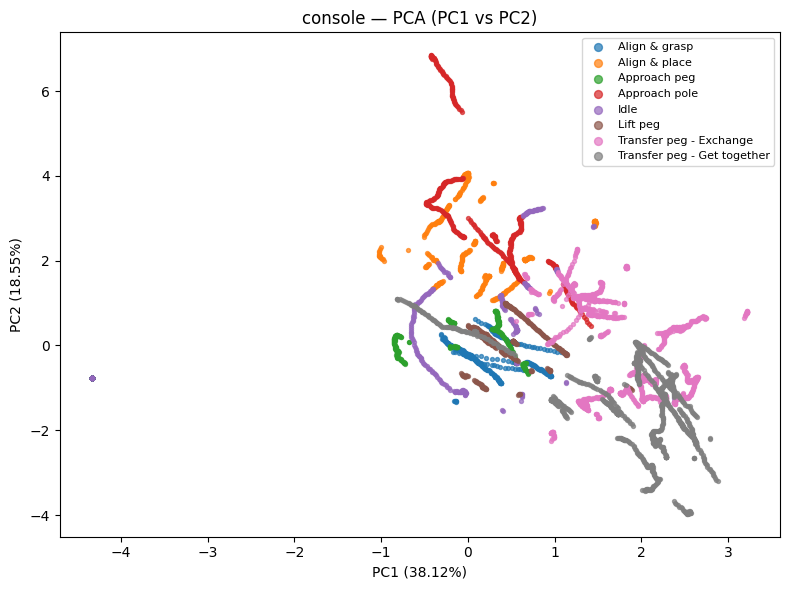

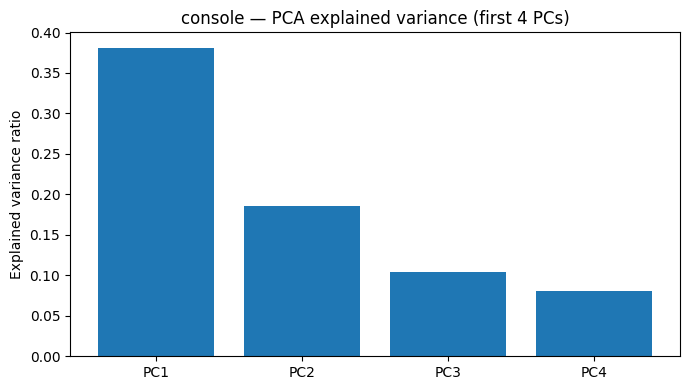

[Info] Silhouette on PC1–PC2: -0.038  (≈[-1,1], higher=better separation)
[Info] Cumulative explained variance:
  PCs 1..1: 38.12%
  PCs 1..2: 56.67%
  PCs 1..3: 67.07%
  PCs 1..4: 75.10%


['frame_number',
 'timestamp',
 'gesture_code',
 'gesture_name',
 'obs_frame_idx',
 'server_time',
 'trakstar_time_ns',
 'trakstar_delta_ns',
 'sw_left_time_ns',
 'sw_left_delta_ns',
 'sw_right_time_ns',
 'sw_right_delta_ns',
 'raven_console_time_ns',
 'raven_console_delta_ns',
 'trakstar_sensor_0_azimuth',
 'trakstar_sensor_1_azimuth',
 'trakstar_sensor_2_azimuth',
 'trakstar_sensor_3_azimuth',
 'trakstar_sensor_0_elevation',
 'trakstar_sensor_1_elevation',
 'trakstar_sensor_2_elevation',
 'trakstar_sensor_3_elevation',
 'trakstar_sensor_0_roll',
 'trakstar_sensor_1_roll',
 'trakstar_sensor_2_roll',
 'trakstar_sensor_3_roll',
 'trakstar_sensor_0_x',
 'trakstar_sensor_1_x',
 'trakstar_sensor_2_x',
 'trakstar_sensor_3_x',
 'trakstar_sensor_0_y',
 'trakstar_sensor_1_y',
 'trakstar_sensor_2_y',
 'trakstar_sensor_3_y',
 'trakstar_sensor_0_z',
 'trakstar_sensor_1_z',
 'trakstar_sensor_2_z',
 'trakstar_sensor_3_z',
 'trakstar_grasp_d0',
 'trakstar_grasp_d1',
 'trakstar_sensor_1_x_transformed

In [47]:
do_pca_analysis()
['frame_number', 'timestamp', 'gesture_code', 'gesture_name', 'obs_frame_idx', 'server_time', 'trakstar_time_ns', 'trakstar_delta_ns', 'sw_left_time_ns', 'sw_left_delta_ns', 'sw_right_time_ns', 'sw_right_delta_ns', 'raven_console_time_ns', 'raven_console_delta_ns', 'trakstar_sensor_0_azimuth', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_azimuth', 'trakstar_sensor_3_azimuth', 'trakstar_sensor_0_elevation', 'trakstar_sensor_1_elevation', 'trakstar_sensor_2_elevation', 'trakstar_sensor_3_elevation', 'trakstar_sensor_0_roll', 'trakstar_sensor_1_roll', 'trakstar_sensor_2_roll', 'trakstar_sensor_3_roll', 'trakstar_sensor_0_x', 'trakstar_sensor_1_x', 'trakstar_sensor_2_x', 'trakstar_sensor_3_x', 'trakstar_sensor_0_y', 'trakstar_sensor_1_y', 'trakstar_sensor_2_y', 'trakstar_sensor_3_y', 'trakstar_sensor_0_z', 'trakstar_sensor_1_z', 'trakstar_sensor_2_z', 'trakstar_sensor_3_z', 'trakstar_grasp_d0', 'trakstar_grasp_d1', 'trakstar_sensor_1_x_transformed', 'trakstar_sensor_1_y_transformed', 'trakstar_sensor_1_z_transformed', 'trakstar_sensor_2_x_transformed', 'trakstar_sensor_2_y_transformed', 'trakstar_sensor_2_z_transformed', 'trakstar_sensor_0_x_transformed', 'trakstar_sensor_0_y_transformed', 'trakstar_sensor_0_z_transformed', 'trakstar_sensor_3_x_transformed', 'trakstar_sensor_3_y_transformed', 'trakstar_sensor_3_z_transformed', 'console_pedal_x', 'trakstar_sensor_1_x_transformed_cum', 'trakstar_sensor_1_y_transformed_cum', 'trakstar_sensor_1_z_transformed_cum', 'trakstar_s1_norm_cum', 'trakstar_sensor_2_x_transformed_cum', 'trakstar_sensor_2_y_transformed_cum', 'trakstar_sensor_2_z_transformed_cum', 'trakstar_s2_norm_cum', 'trakstar_sensor_0_x_transformed_cum', 'trakstar_sensor_0_y_transformed_cum', 'trakstar_sensor_0_z_transformed_cum', 'trakstar_s0_norm_cum', 'trakstar_sensor_3_x_transformed_cum', 'trakstar_sensor_3_y_transformed_cum', 'trakstar_sensor_3_z_transformed_cum', 'trakstar_s3_norm_cum', 'sw_left_x', 'sw_left_y', 'sw_left_z', 'sw_right_x', 'sw_right_y', 'sw_right_z', 'seq', 'console_pos0', 'console_pos1', 'console_pos2', 'console_pos3', 'console_pos4', 'console_pos5', 'console_rot0', 'console_rot1', 'console_rot2', 'console_rot3', 'console_rot4', 'console_rot5', 'console_aux0', 'console_aux1', 'console_pedal_y', 'raven_field.pos0', 'raven_field.pos1', 'raven_field.pos2', 'raven_field.pos3', 'raven_field.pos4', 'raven_field.pos5', 'raven_field.ori0', 'raven_field.ori1', 'raven_field.ori2', 'raven_field.ori3', 'raven_field.ori4', 'raven_field.ori5', 'raven_field.ori6', 'raven_field.ori7', 'raven_field.ori8', 'raven_field.ori9', 'raven_field.ori10', 'raven_field.ori11', 'raven_field.ori12', 'raven_field.ori13', 'raven_field.ori14', 'raven_field.ori15', 'raven_field.ori16', 'raven_field.ori17', 'raven_field.grasp_d0', 'raven_field.grasp_d1', 'console_pos0_transformed', 'console_pos1_transformed', 'console_pos2_transformed', 'console_pos3_transformed', 'console_pos4_transformed', 'console_pos5_transformed', 'server_time_ns', 'hand_timestamp_ns', 'hand_Frame', 'hand_left X', 'hand_left Y', 'hand_left Z', 'hand_left Yaw', 'hand_left Pitch', 'hand_left Roll', 'hand_right X', 'hand_right Y', 'hand_right Z', 'hand_right Yaw', 'hand_right Pitch', 'hand_right Roll', 'hand_left_index_tip_X', 'hand_left_index_tip_Y', 'hand_left_index_tip_Z', 'hand_right_index_tip_X', 'hand_right_index_tip_Y', 'hand_right_index_tip_Z', 'hand_left_thumb_tip_X', 'hand_left_thumb_tip_Y', 'hand_left_thumb_tip_Z', 'hand_right_thumb_tip_X', 'hand_right_thumb_tip_Y', 'hand_right_thumb_tip_Z']


[Label] Using: gesture_name
[Modality] console: using 14 columns


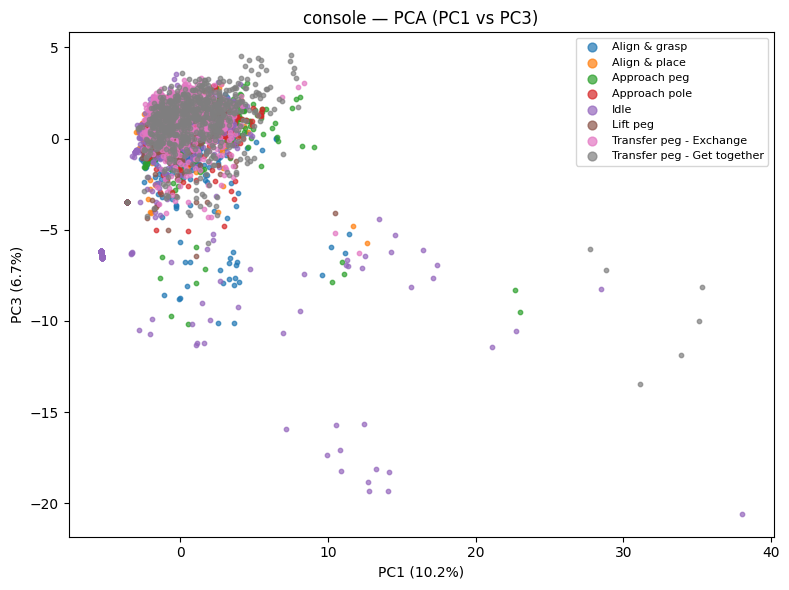

[PCA] Explained variance (first 10): [0.1017 0.0853 0.0668 0.052  0.045  0.0425 0.0349 0.0321 0.029  0.0266]
[PCA] Cumulative (first 10): [0.1017 0.187  0.2538 0.3057 0.3507 0.3932 0.4282 0.4602 0.4893 0.5159]
[Silhouette (2D)] -0.144  (≈[-1,1], higher=better)


In [42]:
#!/usr/bin/env python3
# PCA/LDA/UMAP on kinematic windows with dynamics (vel/acc) and per-group normalization

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Optional: pip install umap-learn
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

# ====== USER CONFIG ======
LABEL_COL = None                 # e.g., "gesture" (auto-guess if None)
SUBJECT_COL = None               # e.g., "subject_id" (for per-subject normalization)
TRIAL_COL = None                 # e.g., "trial_id"   (for per-trial normalization)
GROUP_NORM_BY = None             # choose one of the above: "subject", "trial", or None

MODALITY_KEY = "console"           # pick from MODALITY_COLUMNS keys below
METHOD = "pca"                   # "pca", "lda", or "umap" (needs umap-learn)

# Windowing (frames). If your video is 30 Hz, 30=1s, 60=2s
WINDOW_SIZE = 120
WINDOW_HOP = 30

# Feature engineering
USE_VELOCITY = True              # first differences
USE_ACCELERATION = False         # second differences
SMOOTH_SAVGOL = False            # requires scipy; disabled by default
SAVGOL_WINDOW = 7
SAVGOL_POLY = 2

# Dimensionality parameters
N_COMPONENTS = 16                # for PCA
LDA_COMPONENTS = 2               # <= (n_classes - 1)
UMAP_N_COMPONENTS = 2
UMAP_N_NEIGHBORS = 50
UMAP_MIN_DIST = 0.1

# Plot which 2D projection
PC_PAIR = (1, 3)

SAVE_FIGS = True
OUTDIR = Path("./pca_outputs")
# ==========================

# ====== YOUR COLUMNS ======
MODALITY_COLUMNS = {
    "console": [
        "console_pos0","console_pos1","console_pos2","console_pos3","console_pos4","console_pos5",
        "console_rot0","console_rot1","console_rot2","console_rot3","console_rot4","console_rot5",
        "console_aux0","console_aux1"
    ],
    # "raven": [
    #     "raven_field.pos0","raven_field.pos1","raven_field.pos2","raven_field.pos3","raven_field.pos4","raven_field.pos5",
    #     "raven_field.ori0","raven_field.ori1","raven_field.ori2","raven_field.ori3","raven_field.ori4","raven_field.ori5",
    #     # optionally more ori channels...
    # ],
    # "images": ["resnet"],
    # "trakstar_raw": [
    #     "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
    #     "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
    #     "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
    #     "trakstar_sensor_0_x","trakstar_sensor_1_x","trakstar_sensor_2_x","trakstar_sensor_3_x",
    #     "trakstar_sensor_0_y","trakstar_sensor_1_y","trakstar_sensor_2_y","trakstar_sensor_3_y",
    #     "trakstar_sensor_0_z","trakstar_sensor_1_z","trakstar_sensor_2_z","trakstar_sensor_3_z"
    # ],
    # "trakstar_trans": [
    #     "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
    #     "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
    #     "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
    #     "trakstar_sensor_0_x_transformed","trakstar_sensor_0_y_transformed","trakstar_sensor_0_z_transformed",
    #     "trakstar_sensor_1_x_transformed","trakstar_sensor_1_y_transformed","trakstar_sensor_1_z_transformed",
    #     "trakstar_sensor_2_x_transformed","trakstar_sensor_2_y_transformed","trakstar_sensor_2_z_transformed",
    #     "trakstar_sensor_3_x_transformed","trakstar_sensor_3_y_transformed","trakstar_sensor_3_z_transformed"
    # ],
    # "sw_left": ["sw_left_x"],
    # "sw_right": ["sw_right_x"],
    # "handkp": [
    #     "hand_left X","hand_left Y","hand_left Z","hand_left Yaw","hand_left Pitch","hand_left Roll",
    #     "hand_right X","hand_right Y","hand_right Z","hand_right Yaw","hand_right Pitch","hand_right Roll"
    # ],
}

# ====== HELPERS ======
def guess_label_column(df: pd.DataFrame) -> str:
    preferred = ["gesture","gesture_label","activity","activity_label","label","keystep","keystep_label","gesture_name","class"]
    for p in preferred:
        if p in df.columns or p.title() in df.columns:
            return p if p in df.columns else p.title()
    # fallback: smallest reasonable cardinality non-time column
    candidates = [(c, df[c].nunique()) for c in df.columns if df[c].nunique() > 1 and df[c].nunique() <= 40]
    if candidates:
        candidates.sort(key=lambda x: x[1])
        return candidates[0][0]
    df["_auto_label"] = "all"
    return "_auto_label"

def build_feature_matrix(df: pd.DataFrame, cols: list[str]) -> tuple[np.ndarray, list[str]]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"[Warn] Missing {len(missing)} columns (showing up to 8): {missing[:8]}")
    used = [c for c in cols if c in df.columns]
    if not used:
        raise ValueError("No requested modality columns found.")
    X = df[used].to_numpy()
    return X, used

def maybe_savgol(x: np.ndarray, window: int, poly: int):
    try:
        from scipy.signal import savgol_filter
    except Exception:
        return x
    if window % 2 == 0: window += 1
    if window < 3: return x
    return savgol_filter(x, window_length=window, polyorder=poly, axis=0, mode="interp")

def add_dynamics(X: np.ndarray, use_vel=True, use_acc=False) -> np.ndarray:
    feats = [X]
    if use_vel:
        V = np.diff(X, n=1, axis=0, prepend=X[:1])
        feats.append(V)
    if use_acc:
        A = np.diff(X, n=2, axis=0, prepend=X[:2])
        feats.append(A)
    return np.concatenate(feats, axis=1)

def windowed_features(X: np.ndarray, y: np.ndarray, win: int, hop: int, reducers=("mean","std","energy")):
    """
    X: [T, D], y: [T] frame labels. Returns Xw [N, D*R], yw [N].
    """
    T, D = X.shape
    idxs = np.arange(0, max(1, T - win + 1), hop)
    out = []
    labels = []
    for s in idxs:
        e = min(T, s + win)
        chunk = X[s:e]
        if chunk.shape[0] == 0: continue
        stats = []
        if "mean" in reducers:  stats.append(chunk.mean(axis=0))
        if "std" in reducers:   stats.append(chunk.std(axis=0, ddof=1))
        if "energy" in reducers: stats.append((chunk**2).mean(axis=0))
        feats = np.concatenate(stats, axis=0)
        out.append(feats)
        # choose majority label in window
        labels.append(pd.Series(y[s:e]).mode(dropna=False).iloc[0])
    return np.vstack(out), np.array(labels)

def groupwise_standardize(df: pd.DataFrame, cols: list[str], group_col: str) -> pd.DataFrame:
    def zscore(g):
        return (g - g.mean()) / (g.std(ddof=1) + 1e-8)
    df = df.copy()
    df[cols] = df.groupby(group_col, observed=True)[cols].transform(zscore)
    return df

# ====== MAIN ======
def main():

    list_of_csvs = ["/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t1/synched_data/final_annotation_t1.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t2/synched_data/final_annotation_t2.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t3/synched_data/final_annotation_t3.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t4/synched_data/final_annotation_t4.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t5/synched_data/final_annotation_t5.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t6/synched_data/final_annotation_t6.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t7/synched_data/final_annotation_t7.csv"]

    df = pd.concat([pd.read_csv(f) for f in list_of_csvs], ignore_index=True)

    # Labels
    label_col = LABEL_COL or guess_label_column(df)
    print(f"[Label] Using: {label_col}")
    y = df[label_col].astype(str).values

    # Group-wise normalization (remove subject/trial confounds)
    if GROUP_NORM_BY == "subject" and SUBJECT_COL and SUBJECT_COL in df.columns:
        cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        df = groupwise_standardize(df, cols, SUBJECT_COL)
        print("[Norm] Per-subject z-scoring applied.")
    elif GROUP_NORM_BY == "trial" and TRIAL_COL and TRIAL_COL in df.columns:
        cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        df = groupwise_standardize(df, cols, TRIAL_COL)
        print("[Norm] Per-trial z-scoring applied.")

    # Build feature matrix from selected modality
    if MODALITY_KEY not in MODALITY_COLUMNS:
        raise KeyError(f"MODALITY_KEY '{MODALITY_KEY}' not in {list(MODALITY_COLUMNS.keys())}")
    X, used_cols = build_feature_matrix(df, MODALITY_COLUMNS[MODALITY_KEY])
    print(f"[Modality] {MODALITY_KEY}: using {len(used_cols)} columns")

    # Optional smoothing
    if SMOOTH_SAVGOL:
        X = maybe_savgol(X, SAVGOL_WINDOW, SAVGOL_POLY)

    # Add dynamics
    X = add_dynamics(X, USE_VELOCITY, USE_ACCELERATION)

    # Window → aggregate stats
    Xw, yw = windowed_features(X, y, WINDOW_SIZE, WINDOW_HOP)

    # Standardize window features
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xw)

    # Projection
    if METHOD.lower() == "pca":
        n_comp = max(N_COMPONENTS, max(PC_PAIR))
        pca = PCA(n_components=n_comp).fit(Xs)
        Z = pca.transform(Xs)
        i, j = PC_PAIR[0]-1, PC_PAIR[1]-1
        evr = pca.explained_variance_ratio_
        title = f"{MODALITY_KEY} — PCA (PC{PC_PAIR[0]} vs PC{PC_PAIR[1]})"
        xlab = f"PC{PC_PAIR[0]} ({evr[i]:.1%})"; ylab = f"PC{PC_PAIR[1]} ({evr[j]:.1%})"
    elif METHOD.lower() == "lda":
        # LDA dims limited to n_classes-1
        n_classes = np.unique(yw).size
        n_lda = min(LDA_COMPONENTS, max(1, n_classes-1))
        lda = LDA(n_components=n_lda).fit(Xs, yw)
        Z = lda.transform(Xs)
        # project to 2D: if n_lda==1, pad with zeros for plotting
        if Z.shape[1] == 1:
            Z = np.hstack([Z, np.zeros_like(Z)])
        i, j = 0, 1
        title = f"{MODALITY_KEY} — LDA (max separation)"
        xlab = "LD1"; ylab = "LD2"
    elif METHOD.lower() == "umap":
        if not HAS_UMAP:
            raise RuntimeError("umap-learn not installed. `pip install umap-learn`")
        reducer = umap.UMAP(n_components=UMAP_N_COMPONENTS, n_neighbors=UMAP_N_NEIGHBORS,
                            min_dist=UMAP_MIN_DIST, metric="euclidean", random_state=42)
        Z = reducer.fit_transform(Xs)
        # if n_components>2, take first 2 for plotting
        i, j = 0, 1
        title = f"{MODALITY_KEY} — UMAP (n={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST})"
        xlab = "UMAP-1"; ylab = "UMAP-2"
    else:
        raise ValueError("METHOD must be 'pca', 'lda', or 'umap'.")

    # Plot
    plt.figure(figsize=(8,6))
    cats = pd.Series(yw).astype("category")
    codes = cats.cat.codes.values
    for code in np.unique(codes):
        sel = codes == code
        plt.scatter(Z[sel, i], Z[sel, j], s=10, alpha=0.7, label=str(cats.cat.categories[code]))
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.tight_layout()
    if SAVE_FIGS:
        OUTDIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(OUTDIR / f"{MODALITY_KEY}_{METHOD}_scatter.png", dpi=200)
    plt.show()

    # Diagnostics
    if METHOD.lower() == "pca":
        cum = np.cumsum(evr)
        print("[PCA] Explained variance (first 10):", np.round(evr[:10], 4))
        print("[PCA] Cumulative (first 10):", np.round(cum[:10], 4))
    # Silhouette on the plotted 2D
    if len(np.unique(yw)) > 1:
        try:
            sil = silhouette_score(Z[:, [i, j]], cats.cat.codes.values)
            print(f"[Silhouette (2D)] {sil:.3f}  (≈[-1,1], higher=better)")
        except Exception as e:
            print(f"[Silhouette] failed: {e}")

main()



Loading 7 trials...

[Image] Processing final_annotation_t1.csv...
  Dropped 4253 Idle rows
  Using label column: 'gesture_name'
  Loaded ResNet features: (11255, 2048)
  → Kept 21 segments: len min=16, mean=273.8, max=622
[Image] Processing final_annotation_t2.csv...
  Dropped 1096 Idle rows
  Loaded ResNet features: (10049, 2048)
  → Kept 26 segments: len min=69, mean=305.2, max=1269
[Image] Processing final_annotation_t3.csv...
  Dropped 3546 Idle rows
  Loaded ResNet features: (13413, 2048)
  → Kept 42 segments: len min=11, mean=180.6, max=460
[Image] Processing final_annotation_t4.csv...
  Dropped 2981 Idle rows
  Loaded ResNet features: (26633, 2048)
  → Kept 71 segments: len min=12, mean=211.0, max=873
[Image] Processing final_annotation_t5.csv...
  Dropped 1083 Idle rows
  Loaded ResNet features: (7877, 2048)
  → Kept 18 segments: len min=54, mean=246.5, max=813
[Image] Processing final_annotation_t6.csv...
  Dropped 2758 Idle rows
  Loaded ResNet features: (21266, 2048)
  → K

/tmp/ipykernel_810349/1787462279.py:331: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(class_order))



[Saved] Figure: pca_outputs/pca_segmentwise_img_resnet_vs_trakstar_sw.png


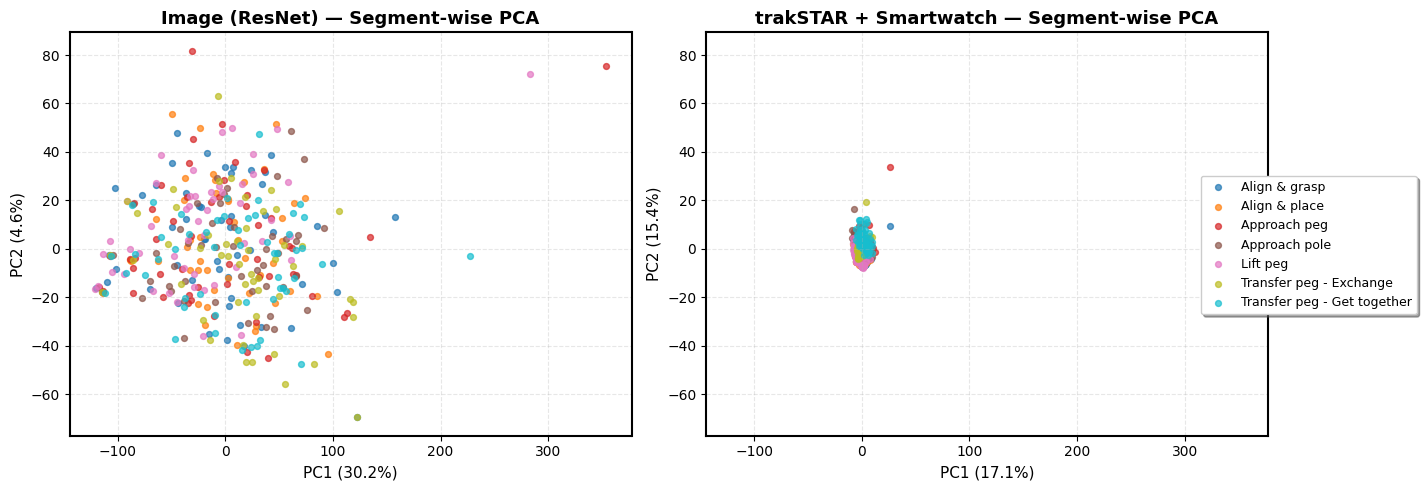


Quantitative Metrics:
Silhouette Score (2D):
  Image:      -0.112
  trakSTAR:   -0.058
  (Higher is better, range [-1, 1])



In [40]:
#!/usr/bin/env python3
# Segment-wise PCA (no fixed windows): Image (ResNet .npy) vs trakSTAR + Smartwatch (IMU)

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ====== CONFIG ======
PC_PAIR = (1, 2)          # PC1 vs PC2
N_COMPONENTS_FOR_IMAGE = 128
N_COMPONENTS_FOR_KINEMATIC = 2
SAVE_FIGS = True
OUTDIR = Path("./pca_outputs")
REDUCERS = ("mean", "std", "range")    # Simplified reducers
ADD_DYNAMICS = True                     # compute vel/acc inside each segment
USE_VEL = True
USE_ACC = False

# Feature selection options
USE_ONLY_POSITIONS = False     # Set True to use only position features
USE_ONLY_ORIENTATIONS = False  # Set True to use only orientation features

# Idle class names
IDLE_NAMES = {"Idle", "idle", "IDLE", 0, "0"}

# Minimum frames per segment
MIN_SEGMENT_LENGTH = 5

# Per-trial normalization (set False if causing issues)
USE_TRIAL_NORMALIZATION = False

def drop_classes(X, y, banned):
    y_ser = pd.Series(y)
    keep = ~y_ser.isin(banned)
    return X[keep.values], y_ser[keep.values].astype(str).values


# ====== INPUT FILES ======
LIST_OF_CSVS = [
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t1/synched_data/final_annotation_t1.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t2/synched_data/final_annotation_t2.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t3/synched_data/final_annotation_t3.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t4/synched_data/final_annotation_t4.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t5/synched_data/final_annotation_t5.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t6/synched_data/final_annotation_t6.csv",
    "/standard/UVA-DSA/MIDAS/Organized/final_data/t7/synched_data/final_annotation_t7.csv",
]

# ====== COLUMN GROUPS (trakSTAR + smartwatch in CSVs) ======
COLS_TRAKSTAR_TRANS = [
    "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
    "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
    "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
    "trakstar_sensor_0_x_transformed","trakstar_sensor_0_y_transformed","trakstar_sensor_0_z_transformed",
    "trakstar_sensor_1_x_transformed","trakstar_sensor_1_y_transformed","trakstar_sensor_1_z_transformed",
    "trakstar_sensor_2_x_transformed","trakstar_sensor_2_y_transformed","trakstar_sensor_2_z_transformed",
    "trakstar_sensor_3_x_transformed","trakstar_sensor_3_y_transformed","trakstar_sensor_3_z_transformed"
]
COLS_SW_LEFT  = ["sw_left_x"]
COLS_SW_RIGHT = ["sw_right_x"]

# ====== HELPERS ======
def guess_label_column(df: pd.DataFrame) -> str:
    preferred = ["gesture","gesture_label","activity","activity_label","label","keystep","keystep_label","gesture_name","class"]
    for p in preferred:
        if p in df.columns: return p
        if p.title() in df.columns: return p.title()
    # fallback: smallest low-cardinality non-time column
    candidates = [(c, df[c].nunique()) for c in df.columns if 1 < df[c].nunique() <= 40]
    if candidates:
        candidates.sort(key=lambda x: x[1])
        return candidates[0][0]
    df["_auto_label"] = "all"
    return "_auto_label"

def infer_trial_id(csv_path: Path) -> str:
    # Match tN from filename or parent folder name
    m = re.search(r'(t\d+)', csv_path.stem, flags=re.IGNORECASE)
    if m: return m.group(1).lower()
    return csv_path.parent.parent.name.lower()

def find_resnet_npy_for_csv(csv_path: Path) -> Path:
    trial_id = infer_trial_id(csv_path)         # e.g., "t1"
    trial_dir = csv_path.parent.parent          # .../t1/
    return trial_dir / f"synched_data/{trial_id}_resnet.npy"

def segment_indices(labels: np.ndarray) -> list[tuple[int,int,str]]:
    """Return list of (start, end_exclusive, label) for contiguous same-label runs."""
    if len(labels) == 0: return []
    segs = []
    s = 0
    cur = labels[0]
    for i in range(1, len(labels)):
        if labels[i] != cur:
            segs.append((s, i, cur))
            s = i
            cur = labels[i]
    segs.append((s, len(labels), cur))
    return segs

def add_dynamics_array(X: np.ndarray, use_vel=True, use_acc=False) -> np.ndarray:
    feats = [X]
    if use_vel:
        V = np.diff(X, n=1, axis=0, prepend=X[:1])
        feats.append(V)
    if use_acc:
        A = np.diff(X, n=2, axis=0, prepend=X[:2])
        feats.append(A)
    return np.concatenate(feats, axis=1)

def reduce_segment(chunk: np.ndarray, reducers=("mean","std","range")) -> np.ndarray:
    stats = []
    if "mean"   in reducers: stats.append(chunk.mean(axis=0))
    if "std"    in reducers: stats.append(chunk.std(axis=0, ddof=1))
    if "median" in reducers: stats.append(np.median(chunk, axis=0))
    if "iqr"    in reducers:
        q75 = np.percentile(chunk, 75, axis=0); q25 = np.percentile(chunk, 25, axis=0)
        stats.append(q75 - q25)
    if "range"  in reducers: stats.append(chunk.max(axis=0) - chunk.min(axis=0))
    if "slope"  in reducers: stats.append(chunk[-1] - chunk[0])
    if "energy" in reducers: stats.append((chunk**2).mean(axis=0))
    if "length" in reducers: stats.append(np.full((chunk.shape[1],), chunk.shape[0], dtype=float))
    return np.concatenate(stats, axis=0) if stats else chunk.mean(axis=0)

def segmentwise_features_from_frames(X_frames: np.ndarray, y_frames: np.ndarray,
                                     add_dyn=True, reducers=("mean","std","range")):
    """Turn frame-level (T,D) into segment-level (N_seg, D*) based on contiguous labels."""
    if add_dyn:
        X_frames = add_dynamics_array(X_frames, use_vel=USE_VEL, use_acc=USE_ACC)
    segs = segment_indices(y_frames)
    Xs, ys, lens = [], [], []
    for s, e, lab in segs:
        chunk = X_frames[s:e]
        if chunk.shape[0] < MIN_SEGMENT_LENGTH:
            continue
        lens.append(chunk.shape[0])
        Xs.append(reduce_segment(chunk, reducers))
        ys.append(str(lab))
    if Xs:
        print(f"  → Kept {len(Xs)} segments: len min={min(lens)}, mean={np.mean(lens):.1f}, max={max(lens)}")
    return (np.vstack(Xs), np.array(ys)) if Xs else (np.empty((0,0)), np.array([]))

def groupwise_standardize(df: pd.DataFrame, cols: list[str], group_col: str) -> pd.DataFrame:
    def zscore(g):
        return (g - g.mean()) / (g.std(ddof=1) + 1e-8)
    out = df.copy()
    out[cols] = out.groupby(group_col, observed=True)[cols].transform(zscore)
    return out

def pca_project(X: np.ndarray, n_comp: int, pair=(1,2), name=""):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X)
    
    # Diagnostic: verify scaling
    print(f"  [{name}] After scaling: std per column min={Xs.std(axis=0).min():.4f}, max={Xs.std(axis=0).max():.4f}")
    
    pca = PCA(n_components=max(n_comp, max(pair))).fit(Xs)
    Z = pca.transform(Xs)
    i, j = pair[0]-1, pair[1]-1
    evr = pca.explained_variance_ratio_
    return Z[:, [i, j]], (evr[i], evr[j])


# ====== MAIN ======
def main():
    csv_paths = [Path(p) for p in LIST_OF_CSVS if Path(p).exists()]
    if not csv_paths:
        raise RuntimeError("No valid CSV paths found. Check LIST_OF_CSVS.")
    
    print(f"\n{'='*60}")
    print(f"Loading {len(csv_paths)} trials...")
    print(f"{'='*60}\n")

    # --- Load IMAGE segments (ResNet .npy per trial) ---
    X_img_seg_list, y_img_seg_list = [], []
    label_col_global = None
    
    for cpath in csv_paths:
        print(f"[Image] Processing {cpath.name}...")
        df = pd.read_csv(cpath)
        
        # Drop Idle rows
        if 'gesture_code' in df.columns:
            before = len(df)
            df = df[~df['gesture_code'].isin(IDLE_NAMES)]
            print(f"  Dropped {before - len(df)} Idle rows")
        
        # Drop NaN
        df = df.dropna()
        
        if label_col_global is None:
            label_col_global = guess_label_column(df)
            print(f"  Using label column: '{label_col_global}'")
        
        y = df[label_col_global].astype(str).values
        
        npy_path = find_resnet_npy_for_csv(cpath)
        if not npy_path.exists():
            print(f"  [Warn] Missing image npy: {npy_path} (skipping)")
            continue
        
        feats = np.load(npy_path)  # [T, D]
        if feats.ndim != 2:
            raise ValueError(f"ResNet npy must be 2D [T,D], got {feats.shape} at {npy_path}")
        print(f"  Loaded ResNet features: {feats.shape}")
        
        T_common = min(len(y), feats.shape[0])
        if T_common <= MIN_SEGMENT_LENGTH:
            print(f"  [Warn] Too few frames ({T_common}), skipping.")
            continue
        
        X_seg, y_seg = segmentwise_features_from_frames(
            feats[:T_common], y[:T_common],
            add_dyn=ADD_DYNAMICS, reducers=REDUCERS
        )
        if X_seg.size:
            X_img_seg_list.append(X_seg)
            y_img_seg_list.append(y_seg)

    if not X_img_seg_list:
        raise RuntimeError("No image segments found across trials.")
    
    X_img = np.vstack(X_img_seg_list)
    y_img = np.concatenate(y_img_seg_list)
    
    print(f"\n[Image] Total segments before filtering: {len(y_img)}")
    X_img, y_img = drop_classes(X_img, y_img, IDLE_NAMES)
    print(f"[Image] Segments after dropping Idle: {len(y_img)}")
    print(f"[Image] Final feature shape: {X_img.shape}")
    print(f"[Image] Unique classes: {np.unique(y_img)}")

    # --- Load trakSTAR + Smartwatch data ---
    print(f"\n{'='*60}")
    print(f"Loading trakSTAR + Smartwatch data...")
    print(f"{'='*60}\n")
    
    df_all = pd.concat([
        pd.read_csv(p).assign(__trial=p.parent.parent.name) 
        for p in csv_paths
    ], ignore_index=True)
    
    print(f"[trakSTAR] Total frames loaded: {len(df_all)}")
    
    # Drop Idle
    if "gesture_code" in df_all.columns:
        before = len(df_all)
        df_all = df_all[~df_all["gesture_code"].isin(IDLE_NAMES)]
        print(f"[trakSTAR] Dropped {before - len(df_all)} Idle rows")
    
    # Drop NaN
    df_all = df_all.dropna()
    print(f"[trakSTAR] Frames after dropna: {len(df_all)}")
    
    # Optional per-trial normalization
    if USE_TRIAL_NORMALIZATION:
        print("[trakSTAR] Applying per-trial z-score normalization...")
        num_cols = [c for c in df_all.columns if pd.api.types.is_numeric_dtype(df_all[c])]
        df_all = groupwise_standardize(df_all, num_cols, "__trial")
    
    # Determine label column
    if label_col_global not in df_all.columns:
        alt = label_col_global.title()
        label_col = alt if alt in df_all.columns else guess_label_column(df_all)
    else:
        label_col = label_col_global
    
    print(f"[trakSTAR] Using label column: '{label_col}'")
    print(f"[trakSTAR] Unique labels: {df_all[label_col].nunique()}")
    print(f"[trakSTAR] Label distribution:\n{df_all[label_col].value_counts()}\n")
    
    # Select feature columns
    if USE_ONLY_POSITIONS:
        used_cols = [c for c in COLS_TRAKSTAR_TRANS if 'transformed' in c]
        print("[trakSTAR] Using ONLY position features")
    elif USE_ONLY_ORIENTATIONS:
        used_cols = [c for c in COLS_TRAKSTAR_TRANS if any(x in c for x in ['azimuth','elevation','roll'])]
        print("[trakSTAR] Using ONLY orientation features")
    else:
        cols_trak_sw = COLS_TRAKSTAR_TRANS + COLS_SW_LEFT + COLS_SW_RIGHT
        used_cols = [c for c in cols_trak_sw if c in df_all.columns]
        print("[trakSTAR] Using ALL trakSTAR + Smartwatch features")
    
    if not used_cols:
        raise RuntimeError("No trakSTAR/smartwatch columns found in CSVs.")
    
    print(f"[trakSTAR] Selected {len(used_cols)} feature columns")
    
    X_trk_frames = df_all[used_cols].to_numpy()
    y_trk_frames = df_all[label_col].astype(str).values
    
    print(f"[trakSTAR] Frame-level features: {X_trk_frames.shape}")
    
    X_trk, y_trk = segmentwise_features_from_frames(
        X_trk_frames, y_trk_frames, add_dyn=ADD_DYNAMICS, reducers=REDUCERS
    )
    
    if not X_trk.size:
        raise RuntimeError("No trakSTAR+SW segments produced.")
    
    print(f"[trakSTAR] Segments before filtering: {len(y_trk)}")
    X_trk, y_trk = drop_classes(X_trk, y_trk, IDLE_NAMES)  # FIXED: was X_trk_frames, y_trk_frames
    print(f"[trakSTAR] Segments after dropping Idle: {len(y_trk)}")
    print(f"[trakSTAR] Final feature shape: {X_trk.shape}")
    print(f"[trakSTAR] Unique classes: {np.unique(y_trk)}")
    
    # --- Diagnostics ---
    print(f"\n{'='*60}")
    print("Feature Statistics:")
    print(f"{'='*60}")
    print(f"[Image] Feature range: min={X_img.min():.3f}, max={X_img.max():.3f}, std={X_img.std():.3f}")
    print(f"[Image] Feature std per column: min={X_img.std(axis=0).min():.4f}, max={X_img.std(axis=0).max():.4f}")
    print(f"[trakSTAR] Feature range: min={X_trk.min():.3f}, max={X_trk.max():.3f}, std={X_trk.std():.3f}")
    print(f"[trakSTAR] Feature std per column: min={X_trk.std(axis=0).min():.4f}, max={X_trk.std(axis=0).max():.4f}")
    print()

    # --- PCA per modality (segment-level) ---
    print(f"{'='*60}")
    print("Computing PCA...")
    print(f"{'='*60}")
    Z_img, (evx_i, evy_i) = pca_project(X_img, N_COMPONENTS_FOR_IMAGE, pair=PC_PAIR, name="Image")
    Z_trk, (evx_t, evy_t) = pca_project(X_trk, N_COMPONENTS_FOR_KINEMATIC, pair=PC_PAIR, name="trakSTAR")

    # Consistent class ordering/colors across both plots
    cats_all = pd.Series(np.concatenate([y_img, y_trk])).astype("category")
    class_order = list(cats_all.cat.categories)
    cmap = plt.cm.get_cmap('tab10', len(class_order))

    # Shared axis limits
    x_min = min(Z_img[:,0].min(), Z_trk[:,0].min())
    x_max = max(Z_img[:,0].max(), Z_trk[:,0].max())
    y_min = min(Z_img[:,1].min(), Z_trk[:,1].min())
    y_max = max(Z_img[:,1].max(), Z_trk[:,1].max())
    pad_x = 0.05 * (x_max - x_min + 1e-9)
    pad_y = 0.05 * (y_max - y_min + 1e-9)

    # --- Plot side-by-side with borders ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)

    def scatter_by_class(ax, Z, labels, title, evx, evy):
        cats_local = pd.Series(labels).astype("category")
        for ci, cls in enumerate(class_order):
            sel = (cats_local == cls).values
            ax.scatter(Z[sel,0], Z[sel,1], s=18, alpha=0.7, label=str(cls), c=[cmap(ci)])
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel(f"PC{PC_PAIR[0]} ({evx:.1%})", fontsize=11)
        ax.set_ylabel(f"PC{PC_PAIR[1]} ({evy:.1%})", fontsize=11)
        ax.set_xlim(x_min - pad_x, x_max + pad_x)
        ax.set_ylim(y_min - pad_y, y_max + pad_y)
        ax.grid(True, alpha=0.3, linestyle='--')
        # Border
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_color('black')

    scatter_by_class(axes[0], Z_img, y_img, "Image (ResNet) — Segment-wise PCA", evx_i, evy_i)
    scatter_by_class(axes[1], Z_trk, y_trk, "trakSTAR + Smartwatch — Segment-wise PCA", evx_t, evy_t)

    # Single legend to the right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.02, 0.5), 
               fontsize=9, frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    OUTDIR.mkdir(parents=True, exist_ok=True)
    if SAVE_FIGS:
        out_path = OUTDIR / "pca_segmentwise_img_resnet_vs_trakstar_sw.png"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"\n[Saved] Figure: {out_path}")
    plt.show()

    # --- Quick quantitative separability (printed) ---
    print(f"\n{'='*60}")
    print("Quantitative Metrics:")
    print(f"{'='*60}")
    try:
        sil_img = silhouette_score(Z_img, pd.Series(y_img).astype("category").cat.codes.values)
        sil_trk = silhouette_score(Z_trk, pd.Series(y_trk).astype("category").cat.codes.values)
        print(f"Silhouette Score (2D):")
        print(f"  Image:      {sil_img:.3f}")
        print(f"  trakSTAR:   {sil_trk:.3f}")
        print(f"  (Higher is better, range [-1, 1])")
    except Exception as e:
        print(f"[Silhouette] Could not compute: {e}")
    print(f"{'='*60}\n")

if __name__ == "__main__":
    main()